Define the default font sizes to make the figures prettier:

In [1]:
import matplotlib.pyplot as plt
from scipy import signal
import numpy as np
from adsp import jaxfilter, jaxfixedpt
from scipy import signal
import jax
import jax.numpy as jnp
# Force JAX to use float64 for better numerical agreement
jax.config.update("jax_enable_x64", True)

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)
def set_dark_style():
    plt.style.use("default")
    plt.rcParams.update({
        "figure.facecolor": "#000000",
        "axes.facecolor":   "#000000",
        "axes.edgecolor":   "#FFFFFF",
        "axes.labelcolor":  "#FFFFFF",
        "text.color":       "#FFFFFF",
        "xtick.color":      "#FFFFFF",
        "ytick.color":      "#FFFFFF",
        "grid.color":       "#444444",
        "legend.facecolor": "#000000",
        "legend.edgecolor": "#FFFFFF",
        "savefig.facecolor":"#000000",
        "savefig.edgecolor":"#000000",
    })
set_dark_style()

In [2]:
from pathlib import Path

IMAGES_PATH = Path() / "images" / "lms"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=450):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution, bbox_inches='tight')

### 3.6.1 Analytical Examples
Some analytical tools presented so far are employed to characterize two interesting types of adaptive filtering problems. The
problems are also solved with the LMS algorithm.

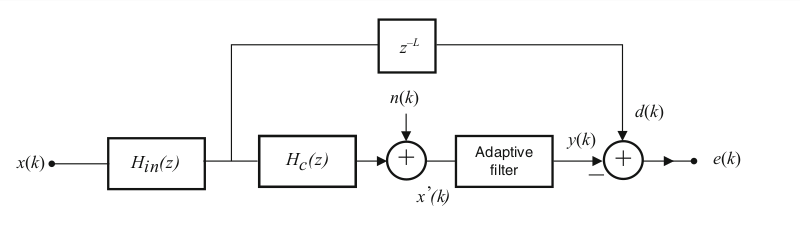

Example 3.1 A Gaussian white-noise sequence (variance $\sigma_{n_1}^2 = 1$) is first colored by

$$
H_{in}(z) = \frac{1}{z - 0.5}
$$

then sent through a communication channel

$$
H_c(z) = \frac{1}{z + 0.8}
$$

and additive channel noise of variance $\sigma_n^2 = 0.1$ is added. The desired signal $d(k)$ is produced by passing the same white noise source through $H_{in}(z)$ and delaying by $L$ samples. We build an adaptive two-tap FIR equalizer (so $M = 2$ taps, i.e., 2 coefficients $w_0, w_1$) and must:

(a) find the best delay $L$,
(b) compute the Wiener solution $w_o$,
(c) choose an appropriate $\mu$ and describe the convergence path,
(d) plot / describe learning curves (single-run and averaged).

#### (a) Choose the best delay $L$

We examine the cross-correlation between the adaptive filter input $x'(k)$ (the channel output) and the desired $d(k)$:

$$
p(i) = E[d(k) \cdot x'(k - i)]
$$

By computing $p(0)$ for small candidate delays $L$ (via contour/residue integration as in the book), the strongest correlation occurs for $L = 1$. In other words, the desired is best aligned with the channel output when delayed by one sample. 

#### (b) Compute the Wiener (optimal) solution

From the book's residue calculations the relevant correlation values (for the two-tap equalizer, i.e. $w = [w_0, w_1]^T$) are:

Cross-correlation vector (for $L = 1$):
$$
p = \begin{bmatrix} p(0) \\ p(1) \end{bmatrix} = \begin{bmatrix} 0.9524 \\ 0.4762 \end{bmatrix}.
$$

Autocorrelation elements of the adaptive filter input $x(k)$ are:
$$
r(0) = 1.6873,
$$
$$
r(1) = -0.7937.
$$

The 2 × 2 input autocorrelation matrix is
$$
R = \begin{bmatrix} 1.6873 & -0.7937 \\ -0.7937 & 1.6873 \end{bmatrix}.
$$

The Wiener (minimum-MSE) solution is
$$
w_o = R^{-1} p.
$$

Carrying out the 2×2 inversion and multiplication (book's values) gives
$$
w_o \approx \begin{bmatrix} 0.8953 \\ 0.7034 \end{bmatrix}.
$$

So the optimal 2-tap equalizer coefficients are approximately
$w_0 = 0.8953$, $w_1 = 0.7034$.

#### (c) Choose $\mu$ and describe convergence path

The book recommends choosing a relatively small step to get a smooth (noisy but stable) path. They used

Step size $\mu$:
$$
\mu = \frac{1}{40 \cdot \text{tr}[R]}.
$$

Here $\text{tr}[R] = 1.6873 + 1.6873 = 3.3746$, so

$$
\mu = \frac{1}{40 \cdot 3.3746} \approx 0.0074.
$$

Wiener solution: [0.89532031 0.70338157]
LMS (ensemble avg): [0.9004766+0.j 0.7065082+0.j]
Error: [0.00515627+0.j 0.00312665+0.j]


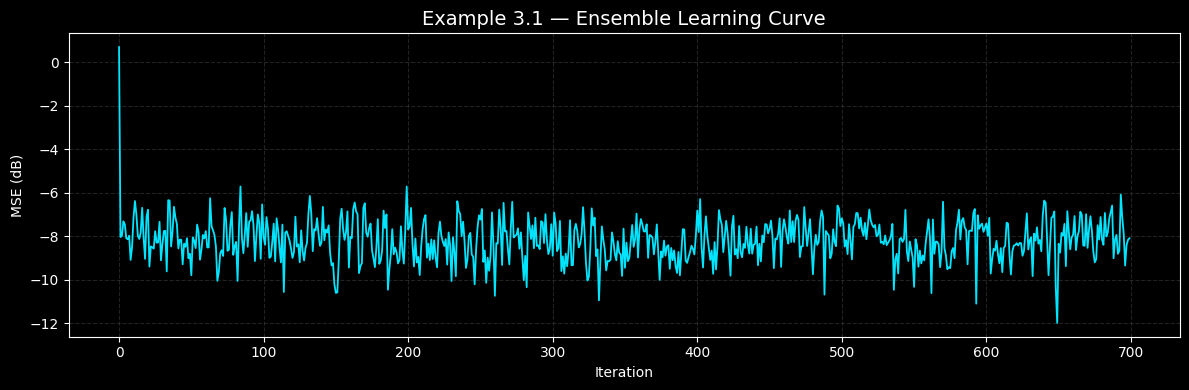

/usr/local/lib/python3.10/dist-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/usr/local/lib/python3.10/dist-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


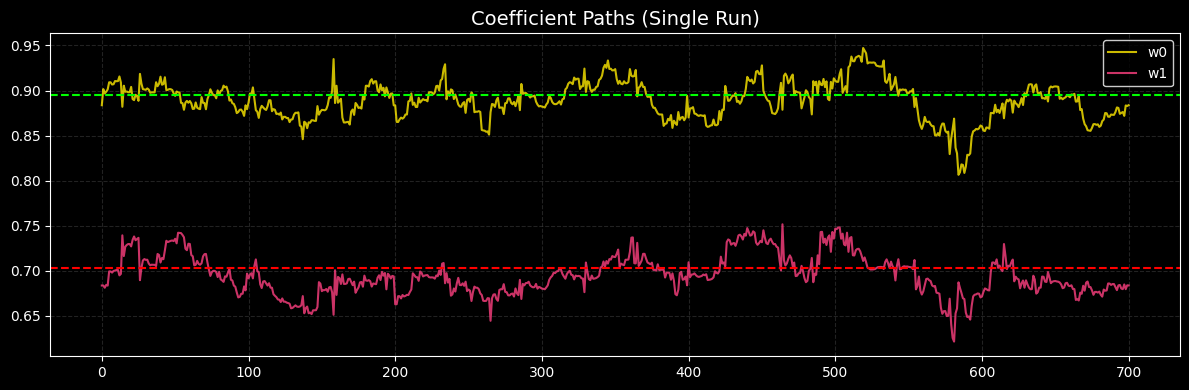

/usr/local/lib/python3.10/dist-packages/matplotlib/transforms.py:758: ComplexWarning: Casting complex values to real discards the imaginary part
  points = np.asarray(points, float)


<BarContainer object of 2 artists>

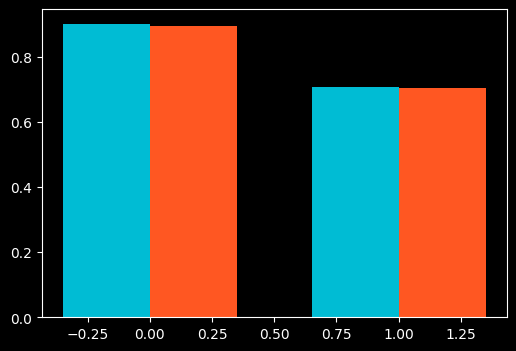

In [3]:
# ============================================================
# Example 3.1 Signal Generator
# ============================================================
def trainSeqs(n_samples: int, key: jax.random.PRNGKey, delay_L: int = 0):
    """Generate input/output signals for Example 3.1 channel equalization."""
    key, subkey1, subkey2 = jax.random.split(key, 3)

    # White Gaussian noise
    u = jax.random.normal(subkey1, (n_samples + 100,), dtype=jnp.float64)

    # H_in(z) = 1 / (1 - 0.5 z^-1)
    def hin_step(carry, u_n):
        y_prev = carry
        y = 0.5 * y_prev + u_n
        return y, y
    _, x_colored = jax.lax.scan(hin_step, 0.0, u)

    # H_c(z) = 1 / (1 + 0.8 z^-1)
    def hc_step(carry, x_n):
        y_prev = carry
        y = -0.8 * y_prev + x_n
        return y, y
    _, x_chan = jax.lax.scan(hc_step, 0.0, x_colored)

    # Add channel noise
    noise = jax.random.normal(subkey2, (n_samples + 100,), dtype=jnp.float64) * jnp.sqrt(0.1)
    x_final = x_chan + noise

    # Desired signal = delayed colored input
    d = jnp.roll(x_colored, delay_L)

    # Remove transients
    return x_final[100:100+n_samples], d[100:100+n_samples]


# ------------------------------------------------------------
# 3. Run LMS with ensemble averaging
# ------------------------------------------------------------
def runLMS(mu, n_samples=700, n_ens=50):
    model = jaxfilter.LMS(mu=mu, filter_order=1)
    key = jax.random.PRNGKey(0)

    mse_ens = []
    w_ens = []

    for k in range(n_ens):
        key, sub = jax.random.split(key)
        x, d = trainSeqs(n_samples, sub)

        variables = model.init(sub, x, d)
        (y_hist, e_hist, w_hist), new_vars = model.apply(
            variables, x, d, train=True, mutable=["state"]
        )

        mse_ens.append(jnp.abs(e_hist)**2)
        w_ens.append(w_hist[-1])

    mse_mean = jnp.mean(jnp.stack(mse_ens), axis=0)
    w_mean = jnp.mean(jnp.stack(w_ens), axis=0)

    return mse_mean, w_mean, w_hist


R = jnp.array([[1.6873, -0.7937],
               [-0.7937, 1.6873]])
p = jnp.array([0.9524, 0.4762])
w_opt = jnp.linalg.solve(R, p)
mu = 1 / (40 * jnp.trace(R))

mse_mean, w_mean, w_hist = runLMS(mu)

print("Wiener solution:", w_opt)
print("LMS (ensemble avg):", w_mean)
print("Error:", w_mean - w_opt)

plt.figure(figsize=(12, 4))
plt.plot(10*jnp.log10(mse_mean + 1e-12),
         color="#00E5FF", linewidth=1.3)      
plt.title("Example 3.1 — Ensemble Learning Curve", fontsize=14)
plt.xlabel("Iteration")
plt.ylabel("MSE (dB)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(w_hist[:,0].real, label="w0", color="#FFEA00", alpha=0.8)   
plt.plot(w_hist[:,1].real, label="w1", color="#FF4081", alpha=0.8) 

# Wiener solutions
plt.axhline(w_opt[0], color="#00FF00", linestyle="--", linewidth=1.5) 
plt.axhline(w_opt[1], color="#FF0000", linestyle="--", linewidth=1.5) 

plt.title("Coefficient Paths (Single Run)", fontsize=14)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(facecolor="#000000", edgecolor="#FFFFFF")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))

x_pos = jnp.array([0, 1])
width = 0.35

plt.bar(x_pos - width/2, w_mean.real, width,
        color="#00BCD4", label="LMS")        
plt.bar(x_pos + width/2, w_opt.real, width,
        color="#FF5722", label="Wiener")    

#### Example 3.2 — First-Order Adaptive Filter

**Problem Statement**  
Suppose in an adaptive filtering environment, the input signal consists of  

$$
x(k) = \cos(\omega_0 k)
$$

and the desired signal is  

$$
d(k) = \sin(\omega_0 k), \qquad \omega_0 = \frac{2\pi}{M}, \; M=7.
$$

Compute the optimal solution for a **first-order adaptive filter**.

---

Since its a terministic and periodc signals, it's not a random process, so it's highly correlated from its past samples.
Since $x(k)$ is not WSS random but deterministic, the usual definition of autocorrelation $R = E[x x^T]$ does not apply in the probabilistic sense.

Instead, we work with time averages:
$$R_{ij} = \lim_{N \to \infty} \frac{1}{N} \sum_{k=0}^{N-1} x(k - i) x(k - j).$$

Since we're working with a first-order adaptive filter, the regressor is two-dimensional:

$$
\mathbf{x}(k) = \begin{bmatrix} x(k) \\ x(k - 1) \end{bmatrix} = \begin{bmatrix} \cos(\omega_0 k) \\ \cos(\omega_0 (k - 1)) \end{bmatrix}
$$

and the Wiener equations become:

$$
\mathbf{R} = \begin{bmatrix}
\mathbb{E}[\cos^2(\omega_0 k)] & \mathbb{E}[\cos(\omega_0 k) \cos(\omega_0 (k - 1))] \\
\mathbb{E}[\cos(\omega_0 (k - 1)) \cos(\omega_0 k)] & \mathbb{E}[\cos^2(\omega_0 (k - 1))]
\end{bmatrix}
$$

$$
\mathbf{p} = \begin{bmatrix}
\mathbb{E}[\sin(\omega_0 k) \cos(\omega_0 k)] \\
\mathbb{E}[\sin(\omega_0 k) \cos(\omega_0 (k - 1))]
\end{bmatrix}
$$

Then the optimal weight vector is:

$$
\mathbf{w}_0 = \mathbf{R}^{-1} \mathbf{p}.
$$

In the below simulation, I choose step size $$\mu = \frac{1}{40 \cdot \text{tr}[R]}.$$

μ = 0.025049696433897053
Wiener w_opt = [-0.79747334  1.27904795]


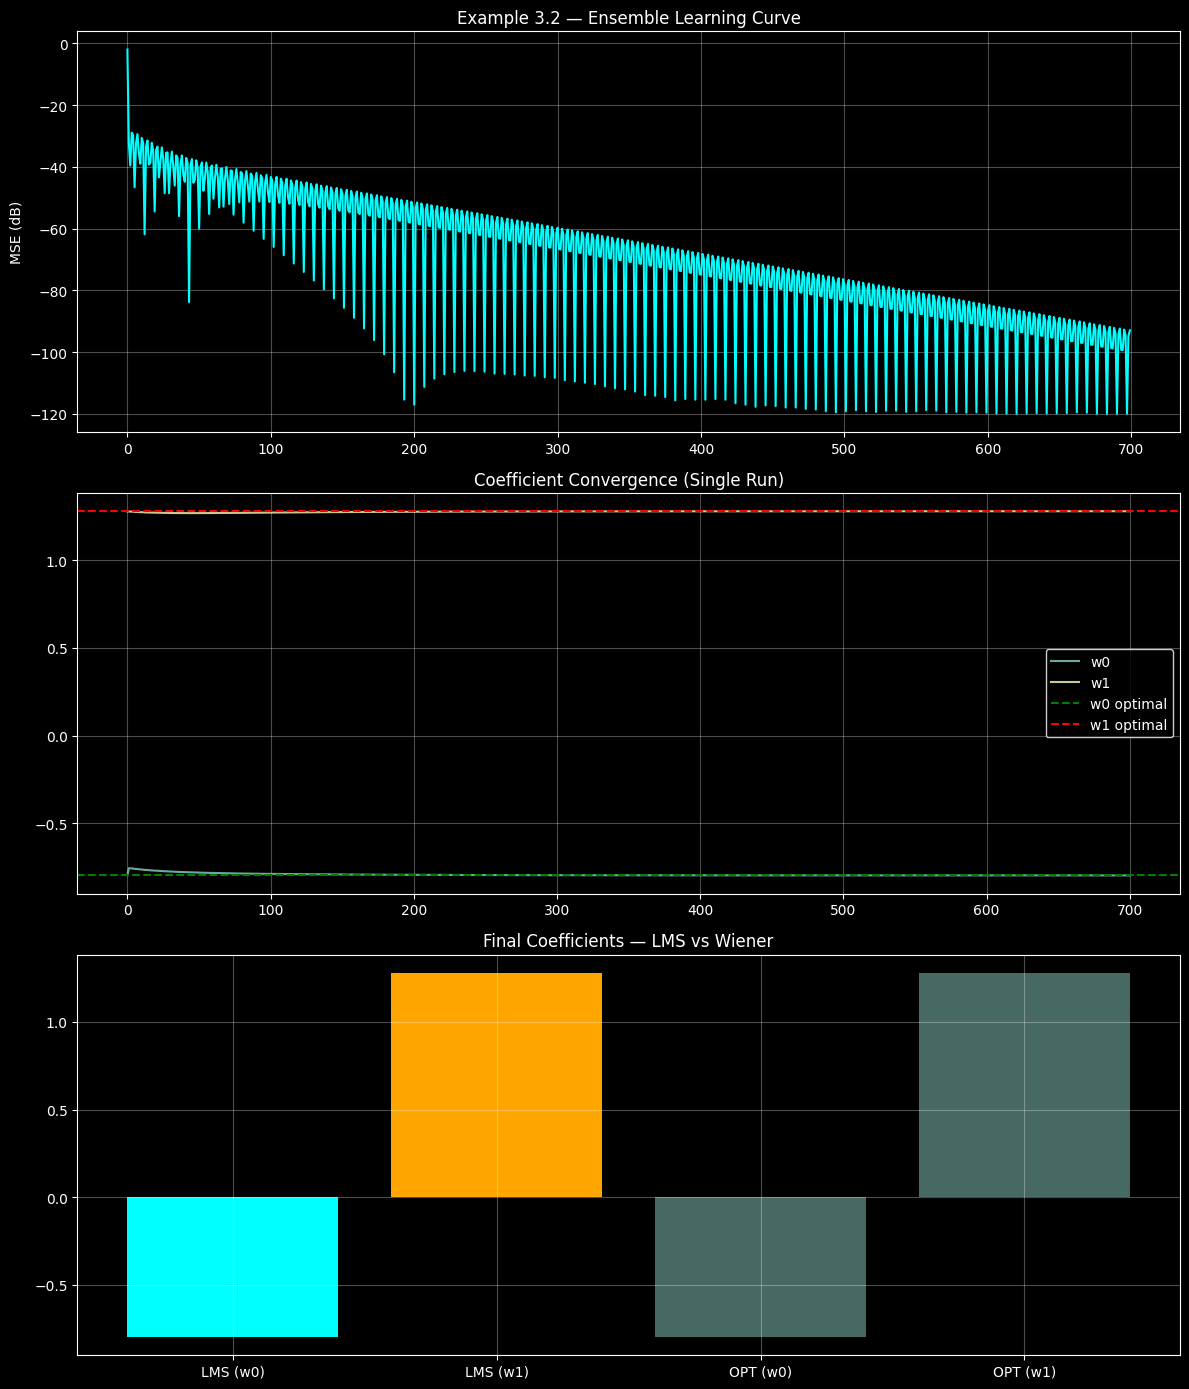


=== FINAL RESULTS ===
Wiener solution: [-0.79747334  1.27904795]
Avg final LMS: [-0.7974473  1.2790223]
Diff: [ 2.60128521e-05 -2.56135657e-05]


In [4]:
# --------------------------------------------
# 1. Deterministic periodic signals
# --------------------------------------------
def trainSeqs(n_samples: int):
    """
    Example 3.2 signal generator: x(k) = cos(ω0 k), d(k) = sin(ω0 k).
    """
    M = 7
    omega0 = 2 * jnp.pi / M
    k = jnp.arange(n_samples, dtype=jnp.float64)

    x = jnp.cos(omega0 * k)
    d = jnp.sin(omega0 * k)

    return x, d
    
# --------------------------------------------
# 2. Compute Wiener solution using time averages
# --------------------------------------------
def wienerSolTimeAvg(x: jnp.ndarray, d: jnp.ndarray, order: int = 1):
    """
    Example 3.2 Wiener solution using time averages (for deterministic inputs).
    Generalized to filter_order = order (so coefficient length = order + 1).
    
    Args:
      x: input signal (1D array)
      d: desired signal (1D array)
      order: filter order (default 1 → two coefficients)
    
    Returns:
      w_opt: optimal Wiener solution
      R: time-averaged autocorrelation matrix
      p: time-averaged cross-correlation vector
    """
    N = len(x)
    n_coef = order + 1

    if N <= n_coef:
        raise ValueError(f"Need more than {n_coef} samples for time-averaged solution")

    # Build regressor matrix
    # Each row: [x[k], x[k-1], ..., x[k-order]]
    X = jnp.stack([x[order - i:N - i] for i in range(n_coef)], axis=1)
    d_use = d[order:N]  # align desired signal

    # Time-average estimates
    R = (X.conj().T @ X) / (N)
    p = (X.conj().T @ d_use) / (N)

    # Regularization for stability
    R_reg = R + 1e-8 * jnp.eye(n_coef, dtype=x.dtype)
    w_opt = jnp.linalg.solve(R_reg, p)

    return w_opt, R, p

def runOneTrial(mu, n_samples):
    model = jaxfilter.LMS(mu=mu, filter_order=1)

    x, d = trainSeqs(n_samples)
    variables = model.init(jax.random.PRNGKey(0), x, d)
    (y_hist, e_hist, w_hist) = model.apply(variables, x, d, mutable=["state"])[0]

    return w_hist, e_hist

# ============================================================
# 5. Ensemble experiment
# ============================================================
def runEnsemble(mu, n_samples, n_ens):
    mse_accum = jnp.zeros(n_samples)
    w_final_list = []
    key: jax.random.PRNGKey
    for i in range(n_ens):
        w_hist, e_hist = runOneTrial(mu, n_samples)
        mse_accum += jnp.abs(e_hist) ** 2
        w_final_list.append(w_hist[-1])

    mse_avg = mse_accum / n_ens
    w_final_avg = jnp.mean(jnp.stack(w_final_list), axis=0)
    return mse_avg, w_final_avg

n_samples = 700
n_ensemble = 50
key = jax.random.PRNGKey(0)
# Compute Wiener solution
x_tmp, d_tmp = trainSeqs(n_samples)
w_opt, R, p = wienerSolTimeAvg(x_tmp, d_tmp)

# Step size: μ = 1/(40·trace(R))
mu = 1 / (40 * jnp.trace(R))
print("μ =", float(mu))
print("Wiener w_opt =", w_opt)

# Ensemble LMS
mse_avg, w_final_avg = runEnsemble(mu, n_samples, n_ensemble)
mse_avg = jnp.real(mse_avg)
w_final_avg = jnp.real(w_final_avg)

# Single-run for plotting
w_hist_single, e_hist_single = runOneTrial(mu, n_samples)

w_hist_single = jnp.real(w_hist_single)
e_hist_single = jnp.real(e_hist_single)

# ============================================================
# 6. PLOTTING
# ============================================================
plt.style.use("dark_background")

fig, axes = plt.subplots(3, 1, figsize=(12, 14))

# Ensemble MSE in dB
axes[0].plot(10 * jnp.log10(mse_avg + 1e-12), color='cyan')
axes[0].set_title("Example 3.2 — Ensemble Learning Curve")
axes[0].set_ylabel("MSE (dB)")
axes[0].grid(True, alpha=0.3)

# Coefficient paths (single run)
axes[1].plot(w_hist_single[:, 0], label="w0", alpha=0.8)
axes[1].plot(w_hist_single[:, 1], label="w1", alpha=0.8)
axes[1].axhline(w_opt[0], color="green", linestyle="--", label="w0 optimal")
axes[1].axhline(w_opt[1], color="red", linestyle="--", label="w1 optimal")
axes[1].set_title("Coefficient Convergence (Single Run)")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

# Final average coefficients
axes[2].bar(["LMS (w0)", "LMS (w1)"], w_final_avg, color=["cyan", "orange"])
axes[2].bar(["OPT (w0)", "OPT (w1)"], w_opt, alpha=0.5)
axes[2].set_title("Final Coefficients — LMS vs Wiener")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n=== FINAL RESULTS ===")
print("Wiener solution:", w_opt)
print("Avg final LMS:", w_final_avg)
print("Diff:", w_final_avg - w_opt)

#### Example 3.3
- Input: two-tone signal, $x(k) = cos(ω₀k) + cos(ω₁k)$
- Desired: $d(k) = sin(ω₀k) + sin(ω₁k)$
- Use **time averages** for R and p since signal is deterministic.
- Wiener solution: $w_o = \overline{\mathbf R}^{-1}\overline{\mathbf{p}}̄$
- Extends Example 3.2: filter now approximates quadrature relationship for *both* tones.

##### Derivation: Time-averaged Wiener solution (deterministic signals)

**Goal.** For deterministic (non-WSS) inputs we replace ensemble expectations by time averages and obtain the Wiener (least–squares) solution as example 3.2
$$
\overline{\mathbf w} \;\approx\; \overline{\mathbf R}^{-1}\,\overline{\mathbf p},
$$
where
$$
\overline{\mathbf R} \;=\; \overline{\mathbf x(k)\mathbf x^T(k)} 
\;=\; \lim_{N\to\infty}\frac{1}{N}\sum_{k=0}^{N-1}\mathbf x(k)\mathbf x^T(k),
\qquad
\overline{\mathbf p} \;=\; \overline{d(k)\mathbf x(k)}
\;=\; \lim_{N\to\infty}\frac{1}{N}\sum_{k=0}^{N-1}d(k)\,\mathbf x(k).
$$

Below is a self-contained derivation for wiener solution (optimal solution) 

---
##### Derivation of the time-averaged LMS update — equation (3.83)

We use the LMS update in the textbook $2\mu$ form (real-valued signals for simplicity):
$$
\mathbf{w}(k+1) = \mathbf{w}(k) + 2\mu e(k) \mathbf{x}(k),
\qquad
e(k) = d(k) - \mathbf{w}^T(k) \mathbf{x}(k).
$$
Expanding the update gives the algebraically equivalent form
$$
\mathbf{w}(k+1) = \big[\mathbf{I} - 2\mu \mathbf{x}(k) \mathbf{x}^T(k)\big] \mathbf{w}(k) + 2\mu d(k) \mathbf{x}(k).
\tag{1}
$$

---

##### 1. Define the moving average (over $M$ samples)

For any time sequence $\mathbf{a}(k)$, define the $M$-point (backward) time average
$$
\overline{\mathbf{a}}(k) \equiv \frac{1}{M} \sum_{m=0}^{M-1} \mathbf{a}(k-m).
\tag{2}
$$

(If $\mathbf{a}(k)$ is $M$-periodic, then $\mathbf{a}(k)$ is independent of $k$

---

##### 2. Apply the update to shifted time indices and average

Write the update (1) for the $M$ shifted times $t = k - m$, $m = 0, \dots, M-1$:
$$
\mathbf{w}(k - m + 1) = \big[\mathbf{I} - 2\mu \mathbf{x}(k - m) \mathbf{x}^T(k - m)\big] \mathbf{w}(k - m) + 2\mu d(k - m) \mathbf{x}(k - m).
$$

Average both sides over $m = 0, \dots, M-1$ and use the linearity of the sum:
$$
\frac{1}{M} \sum_{m=0}^{M-1} \mathbf{w}(k - m + 1) = \frac{1}{M} \sum_{m=0}^{M-1} \big[\mathbf{I} - 2\mu \mathbf{x}(k - m) \mathbf{x}^T(k - m)\big] \mathbf{w}(k - m) + \frac{1}{M} \sum_{m=0}^{M-1} 2\mu d(k - m) \mathbf{x}(k - m).
\tag{3}
$$

By definition of the moving average (2), the left-hand side is $\mathbf{w}(k + 1)$. Thus, we obtain the exact averaged-update identity:

$$
\boxed{
\overline{\mathbf{w}}(k + 1) = \frac{1}{M} \sum_{m=0}^{M-1} \big[\mathbf{I} - 2\mu \mathbf{x}(k - m) \mathbf{x}^T(k - m)\big] \mathbf{w}(k - m) + \frac{1}{M} \sum_{m=0}^{M-1} 2\mu d(k - m) \mathbf{x}(k - m)
}
\tag{3.83}
$$

Equivalently, using the overline shorthand,
$$
\boxed{
\overline{\mathbf{w}}(k + 1) = \overline{\big[\mathbf{I} - 2\mu \mathbf{x}(k) \mathbf{x}^T(k)\big] \mathbf{w}(k)} + \overline{2\mu d(k) \mathbf{x}(k)}
}
\tag{3.83'}
$$

This is an **exact** identity (no approximations yet): it simply averages the shifted, exact updates.

---

##### 3. Usual approximation (decoupling / slow-variation)

To make (3.83) useful, we often assume the filter coefficients vary **slowly** over the averaging window (small step size $\mu$, so that $\mathbf{w}(k - m) \approx \overline{\mathbf{w}}(k)$ for $m = 0, \dots, M-1$. Under this **slow-variation** (or quasi-stationarity) assumption, we can move $\mathbf{w}$ outside the time-average of the multiplicative term:

$$
\overline{\big[\mathbf{I} - 2\mu \mathbf{x}(k) \mathbf{x}^T(k)\big] \mathbf{w}(k)} \approx \Big(\overline{\mathbf{I} - 2\mu \mathbf{x}(k) \mathbf{x}^T(k)}\Big) \overline{\mathbf{w}}(k).
$$

Because $\mathbf{I}$ is constant and the averaging operator is linear,
$$
\overline{\mathbf{I} - 2\mu \mathbf{x}(k) \mathbf{x}^T(k)} = \mathbf{I} - 2\mu \overline{\mathbf{x}(k) \mathbf{x}^T(k)} = \mathbf{I} - 2\mu \overline{\mathbf{R}},
$$
where we define the time-averaged autocorrelation matrix
$$
\overline{\mathbf{R}} = \overline{\mathbf{x}(k) \mathbf{x}^T(k)}.
$$

Similarly,
$$
\overline{2\mu d(k) \mathbf{x}(k)} = 2\mu \overline{d(k) \mathbf{x}(k)} \equiv 2\mu \overline{\mathbf{p}}.
$$

Thus, under the slow-variation approximation, (3.83) becomes
$$
\overline{\mathbf{w}}(k + 1) \approx \big(\mathbf{I} - 2\mu \overline{\mathbf{R}}\big) \overline{\mathbf{w}}(k) + 2\mu \overline{\mathbf{p}}.
\tag{4}
$$

---

##### 4. Steady state and the time-average Wiener solution

At steady state (or for fixed point of the averaged recursion), set $\mathbf{w}(k + 1) = \mathbf{w}(k) = \mathbf{w}$ in (4):
$$
\overline{\mathbf{w}} = \big(\mathbf{I} - 2\mu \overline{\mathbf{R}}\big) \overline{\mathbf{w}} + 2\mu \overline{\mathbf{p}}.
$$

Rearrange:
$$
2\mu \overline{\mathbf{R}} \overline{\mathbf{w}} = 2\mu \overline{\mathbf{p}} \quad \Longrightarrow \quad \overline{\mathbf{R}} \overline{\mathbf{w}} = \overline{\mathbf{p}}.
$$

Provided $\overline{\mathbf{R}}$ is invertible,
$$
\boxed{\quad \overline{\mathbf{w}} = \overline{\mathbf{R}}^{-1} \overline{\mathbf{p}} \quad}
$$
which is the **time-averaged Wiener (least-squares) solution** used for deterministic or periodic inputs.

---

##### 5. Remarks and assumptions

- (3.83) is exact (no approximations); it is simply the average of the exact single-step updates.  
- The step from (3.83) to (4) **requires** the quasi-stationarity/slow-variation assumption (or equivalently that the coefficient vector is almost constant over the averaging window). This is typically justified when $\mu$ is small.  
- If $x(k)$ is periodic with period $M$, then $\overline{\mathbf{R}}$ and $\overline{\mathbf{p}}$ are simply the averages over one period and are time invariant.  
- If $\overline{\mathbf{R}}$ is singular (e.g., single-tone narrowband with filter length large), the inverse is replaced by a pseudo-inverse, and the solution is not unique.

---

**Conclusion.** (3.83) is obtained by averaging the per-time LMS updates. Under slow weight variation, we factor averages and obtain the averaged linear recursion (4), whose fixed point is the time-average Wiener solution $\overline{\mathbf{w}} = \overline{\mathbf{R}}^{-1} \overline{\mathbf{p}}.$


In [5]:
# --------------------------------------------
# Example 3.2 deterministic signals
# --------------------------------------------
def trainSeqs(n_samples: int):
    M = 7
    omega0 = 2 * jnp.pi / M
    k = jnp.arange(n_samples, dtype=jnp.float64)

    x = jnp.cos(omega0 * k)
    d = jnp.sin(omega0 * k)
    return x, d


# --------------------------------------------
# Wiener solution (time averages)
# --------------------------------------------
def wienerSolTimeAvg(x, d, order=1):
    N = len(x)
    n_coef = order + 1

    X = jnp.stack([x[order - i:N - i] for i in range(n_coef)], axis=1)
    d_use = d[order:N]

    R = (X.T @ X) / N
    p = (X.T @ d_use) / N

    R_reg = R + 1e-8 * jnp.eye(n_coef)
    w_opt = jnp.linalg.solve(R_reg, p)

    return w_opt, R, p


# --------------------------------------------
# Single-trial LMS
# --------------------------------------------
def runOneTrial(mu, n_samples):
    model = jaxfilter.LMS(mu=mu, filter_order=1)

    x, d = trainSeqs(n_samples)
    variables = model.init(jax.random.PRNGKey(0), x, d)

    (y_hist, e_hist, w_hist) = model.apply(
        variables, x, d, mutable=["state"]
    )[0]

    return w_hist, e_hist


# --------------------------------------------
# Ensemble experiment
# --------------------------------------------
def runEnsemble(mu, n_samples, n_ens):
    mse_accum = jnp.zeros(n_samples)
    w_final_list = []

    for i in range(n_ens):
        w_hist, e_hist = runOneTrial(mu, n_samples)
        mse_accum += jnp.abs(e_hist)**2
        w_final_list.append(w_hist[-1])

    mse_avg = mse_accum / n_ens
    w_final_avg = jnp.mean(jnp.stack(w_final_list), axis=0)
    return mse_avg, w_final_avg
  
n_samples = 700
n_ensemble = 50

x_tmp, d_tmp = trainSeqs(n_samples)
w_opt, R, p = wienerSolTimeAvg(x_tmp, d_tmp)

mu = 1 / (40 * jnp.trace(R))
print("μ =", float(mu))
print("Wiener w_opt =", w_opt)

mse_avg, w_final_avg = runEnsemble(mu, n_samples, n_ensemble)
w_hist_single, e_hist_single = runOneTrial(mu, n_samples)

μ = 0.025049696433897053
Wiener w_opt = [-0.79747334  1.27904795]


### Example 3.6: System Identification Simulations

**Setup:**
- System to identify: FIR filter with impulse response $\mathbf{h} = [0, 1.0, 3.0, 0, -0.2, -0.4, -0.7, -0.4, -0.2]^T$.
- Adaptive filter order: 8 coefficients (matches length of $\mathbf{h}$).
- Input signal: Colored noise with variance $\sigma_x^2 = 1$ and eigenvalue spread, or Gaussian white noise uncorrelated with input (cases vary).
- Measurement noise: Gaussian white noise with variance $\sigma_n^2$ (specified per case).
- LMS update: $\mathbf{w}(k + 1) = \mathbf{w}(k) + 2\mu e(k) \mathbf{x}(k)$, where $e(k) = d(k) - \mathbf{x}^T(k) \mathbf{w}(k)$.

#### (a) Run Algorithm and Comment on Convergence Behavior
- Run LMS for three cases (colored noise with variance $\sigma_x^2 = 1$ and eigenvalue spreads 10, 20, 80).
- Comment on convergence: Faster convergence expected with smaller eigenvalue spread (e.g., 10) due to reduced condition number of $\mathbf{R}$. Slower convergence with spread 80 due to increased eigenvalue disparity.

#### (b) Measure Misadjustment and Compare with Theoretical Results
- Misadjustment $M = \frac{\mu \text{tr}[\mathbf{R}]}{1 - \mu \text{tr}[\mathbf{R}]}$ (from 3.50).
- For white input, $\text{tr}[\mathbf{R}] = 10 \sigma_x^2 = 10$. Choose $\mu$ to ensure stability ($\mu \text{tr}[\mathbf{R}] < 1$).
- Simulate and compare $M$ with theory. Expected $M \approx \mu \cdot 10$ for small $\mu$ (e.g., $\mu = 0.01$ gives $M \approx 0.1$).

#### (c) Fixed-Point Arithmetic Effects
- Case: $\sigma_n^2 = 0.0015$, coefficient wordlength $b_c = 16$ bits, signal wordlength $b_x = 16$ bits.
- Run experiments, calculate expected $\|\Delta \mathbf{w}(k)\|^2$ and $\xi(k)$:
  - $\|\Delta \mathbf{w}(k)\|^2$: Error due to finite precision, proportional to $2^{-2b_c}$.
  - $\xi(k)$: Excess MSE, includes noise and quantization effects.
- Expected values depend on $\mu$; use small $\mu$ (e.g., $\mu = 0.001$) to minimize instability.

#### (d) Repeat Experiment with Different Wordlengths
- Cases: $b_c = 12$ bits, $b_d = 12$ bits; $b_c = 10$ bits, $b_d = 10$ bits.
- Repeat (c) simulations, expecting increased $\|\Delta \mathbf{w}(k)\|^2$ and $\xi(k)$ with reduced wordlength due to larger quantization errors.

#### (e) Time-Varying System Identification
- System: Time-varying with coefficients as first-order Markov processes, $\lambda_w = 0.99$.
- Input: Gaussian white noise with variance $\sigma_x^2 = 1.0$.
- Measurement noise: Gaussian white noise with variance $\sigma_n^2 = 0.01$.
- Initial $\sigma_w^2 = 0.0015$.
- Simulate, measure total excess MSE $\xi_{\text{total}}$, and compare to calculated:
  - Theoretical $\xi_{\text{total}} \approx \mu \text{tr}[\mathbf{R}] \cdot \sigma_n^2 + \frac{\sigma_n^2}{1 - \mu \lambda_{\max}}$ (for small $\mu$).
  - With $\mu = 0.01$, $\text{tr}[\mathbf{R}] = 10$, $\lambda_{\max} = 1$:
    $$
    \xi_{\text{total}} \approx 0.01 \cdot 10 \cdot 0.01 + \frac{0.01}{1 - 0.01} \approx 0.001 + 0.0101 \approx 0.0111.
    $$
  - Adjust $\mu$ (e.g., $\mu = 0.001$) for stability with time-varying case: $\xi_{\text{total}} \approx 0.0001 + 0.01001 \approx 0.01011$.


=== Running spread=10, AR pole a=0.5195 ===
Final averaged LMS coefficients:
 [ 9.9896841e-02+0.j  2.9993635e-01+0.j  2.3069892e-05+0.j
 -2.0015046e-01+0.j -3.9992630e-01+0.j -7.0005769e-01+0.j
 -3.9996231e-01+0.j -2.0018934e-01+0.j]
Coeff error norm: 0.0002896394747432465

=== Running spread=20, AR pole a=0.6345 ===
Final averaged LMS coefficients:
 [ 9.9989556e-02+0.j  2.9984829e-01+0.j  8.3566149e-05+0.j
 -2.0008144e-01+0.j -4.0009615e-01+0.j -6.9992238e-01+0.j
 -4.0003225e-01+0.j -2.0014387e-01+0.j]
Coeff error norm: 0.00027156894114777584

=== Running spread=80, AR pole a=0.7989 ===
Final averaged LMS coefficients:
 [ 0.10375027+0.j  0.29341188+0.j  0.00419037+0.j -0.19906218+0.j
 -0.40587166+0.j -0.6935207 +0.j -0.40342152+0.j -0.19929644+0.j]
Coeff error norm: 0.012828317485712266


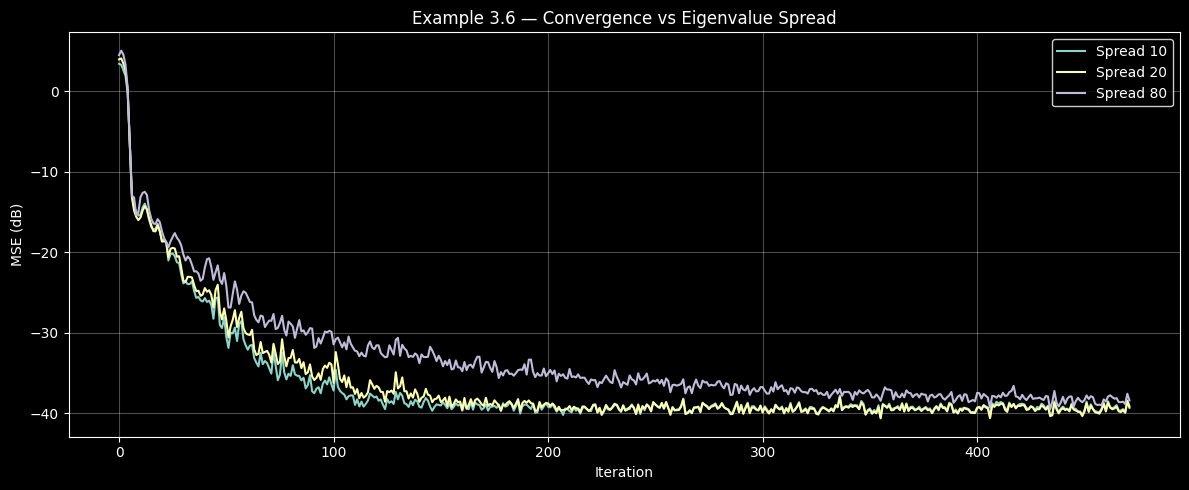

In [10]:
# ------------------------------------------------------------
# True system (Example 3.6)
# ------------------------------------------------------------
h_true = jnp.array([0.1, 0.3, 0.0, -0.2, -0.4, -0.7, -0.4, -0.2])
filter_order = len(h_true) - 1   # → 7 (meaning 8 taps)

def trainSeqs(n_samples: int, key, a: float, sigma_x2=1.0, sigma_n2=1e-4):
    """
    Generates:
      x = AR(1) colored noise
      d = h_true * x + noise
    """
    key, k1, k2 = jax.random.split(key, 3)
    n_warmups = (int)(n_samples * 0.2)
    N = n_samples + n_warmups  # discard transients

    # White noise
    sigma_v2 = sigma_x2 * (1 - a*a)
    u = jax.random.normal(k1, (N,)) * jnp.sqrt(sigma_v2)

    # AR(1): x(k) = a x(k-1) + u(k)
    def ar1(carry, u_n):
        x_prev = carry
        x_now = a * x_prev + u_n
        return x_now, x_now

    _, x_full = jax.lax.scan(ar1, 0.0, u)

    # FIR plant
    d_full = jnp.convolve(x_full, h_true, mode="full")[:len(x_full)]

    # Measurement noise
    noise = jax.random.normal(k2, (len(d_full),)) * jnp.sqrt(sigma_n2)
    d_full = d_full + noise

    # Remove transients
    return x_full[-n_samples:], d_full[-n_samples:]
  
def runOneTrial(mu, n_samples, a, key):
    model = jaxfilter.LMS(mu=mu, filter_order=filter_order)
    x, d = trainSeqs(n_samples, key, a=a)

    variables = model.init(key, x, d)
    (y_hist, e_hist, w_hist) = model.apply(
        variables, x, d, mutable=["state"]
    )[0]

    return w_hist, e_hist

def runEnsemble(mu, n_samples, n_ens, a):
    mse_accum = jnp.zeros(n_samples)
    w_final_list = []

    key = jax.random.PRNGKey(99)

    for i in range(n_ens):
        key, sub = jax.random.split(key)
        w_hist, e_hist = runOneTrial(mu, n_samples, a, sub)

        mse_accum += jnp.abs(e_hist) ** 2
        w_final_list.append(w_hist[-1])

    mse_avg = mse_accum / n_ens
    w_avg = jnp.mean(jnp.stack(w_final_list), axis=0)
    return mse_avg, w_avg
  
# LMS settings
mu_from_spread = {
    10: 0.016,
    20: 0.0128,
    80: 0.01024
}
n_samples = 472
n_ensemble = 200

# Three spreads: 10, 20, 80
spreads = [10, 20, 80]

# Convert eigenvalue spread → AR(1) pole
# This corresponds to the well-known approximate relationship between AR(1) pole 
# a eigenvalue spread S=λ_max /λ_min
def ar1FromSpread(S):
    return (jnp.sqrt(S) - 1) / (jnp.sqrt(S) + 1)

results = {}

for S in spreads:
    a = ar1FromSpread(S)
    print(f"\n=== Running spread={S}, AR pole a={a:.4f} ===")
    mu = mu_from_spread[S]
    mse_avg, w_avg = runEnsemble(mu, n_samples, n_ensemble, a)

    results[S] = (mse_avg, w_avg)

    print("Final averaged LMS coefficients:\n", w_avg)
    print("Coeff error norm:", jnp.linalg.norm(w_avg - h_true))
  
plt.style.use("dark_background")
plt.figure(figsize=(12,5))

for S in spreads:
    mse_avg, _ = results[S]
    plt.plot(10*jnp.log10(mse_avg + 1e-12), label=f"Spread {S}")

plt.title("Example 3.6 — Convergence vs Eigenvalue Spread")
plt.xlabel("Iteration")
plt.ylabel("MSE (dB)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

(c), (d) The LMS algorithm is implemented employing fixed-point arithmetic using 16, 12, and 10 bits for data and coefficient wordlengths. The chosen value of $\mu$ is $0.01$. The learning curves for the MSE are depicted in Figures below, depicting the evolution of $||\Delta\mathbf{w}(k)||_Q^2$ with the number of iterations. The experimental results show that the algorithm still works for such limited precision. In Table 3.2, we present a summary of the results obtained from simulation experiments and a comparison with the results predicted by the theory. The experimental results are obtained by averaging the results of 200 independent runs. The relations employed to calculate the theoretical results shown in Table\,3.2 correspond to (B.26) and (B.32) derived in Appendix B. These relations are repeated here for convenience:
$$
\mathbb{E}[||\Delta\mathbf{w}(k)||_Q^2] = \frac{\mu(\sigma_n^2 + \sigma_e^2)(N+1)}{1-\mu(N+1)\sigma_x^2} + \frac{(N+1)\sigma_{\mathbf{w}}^2}{4\mu\sigma_x^2[1-\mu(N+1)\sigma_x^2]}
$$
$$
\xi(k)_Q = \frac{\sigma_e^2 + \sigma_n^2}{1-\mu(N+1)\sigma_x^2} + \frac{(N+1)\sigma_{\mathbf{w}}^2}{4\mu\sigma_x^2[1-\mu(N+1)\sigma_x^2]}
$$

In [13]:
def quantize(x, bits):
    """Symmetric fixed-point quantization to [-1, 1)."""
    levels = 2 ** (bits - 1)
    x_clipped = jnp.clip(x, -1 + 1/levels, 1 - 1/levels)
    return jnp.round(x_clipped * levels) / levels
  
def trainSeqs(n_samples, key, a, sigma_x2=1.0, sigma_n2=0.0015, bits=10):
    """
    Example 3.6(c)(d) fixed-point system ID signal generator.
    """
    key, k1, k2 = jax.random.split(key, 3)
    N = n_samples + 200

    # White noise with variance sigma_x^2
    sigma_v2 = sigma_x2 * (1 - a*a)
    u = jax.random.normal(k1, (N,)) * jnp.sqrt(sigma_v2)

    # AR(1) coloring
    def ar1(carry, u_n):
        x_prev = carry
        x_now = a * x_prev + u_n
        return x_now, x_now

    _, x_full = jax.lax.scan(ar1, 0.0, u)

    # True system
    h_true = jnp.array([0.1, 0.3, 0.0, -0.2, -0.4, -0.7, -0.4, -0.2])
    d_full = jnp.convolve(x_full, h_true, mode="full")[:len(x_full)]

    # Measurement noise
    noise = jax.random.normal(k2, (N,)) * jnp.sqrt(sigma_n2)
    d_full = d_full + noise

    # Normalize to [-1,1] and quantize
    x_full = quantize(x_full / jnp.max(jnp.abs(x_full)), bits)
    d_full = quantize(d_full / jnp.max(jnp.abs(d_full)), bits)

    return x_full[-n_samples:], d_full[-n_samples:], h_true
  
def lmsFixed(x, d, mu, bits, h_true):
    N = len(x)
    L = len(h_true)
    w = jnp.zeros(L)

    # pad for regressor extraction
    x_pad = jnp.pad(x, (L-1, 0))

    def step(carry, k):
        w = carry

        # dynamic slice: regressor
        reg = jax.lax.dynamic_slice(x_pad, (k,), (L,))[::-1]

        # output
        y = jnp.dot(w, reg)
        e = d[k] - y

        # LMS update (quantized)
        dw = 2 * mu * e * reg
        dw_q = quantize(dw, bits)
        w_new = quantize(w + dw_q, bits)

        return w_new, (w_new, e)

    w_final, (w_hist, e_hist) = jax.lax.scan(step, w, jnp.arange(N))
    return w_hist, e_hist
  
def runOneTrial(mu, n_samples, bits, a, key):
    x, d, h_true = trainSeqs(n_samples, key, a, bits=bits)
    w_hist, e_hist = lmsFixed(x, d, mu, bits, h_true)
    return w_hist, e_hist, h_true
  
def runEnsemble(mu, n_samples, n_ens, bits, a):
    key = jax.random.PRNGKey(0)
    mse_accum = jnp.zeros(n_samples)
    w_final_list = []
    delta_w2_list = []

    for i in range(n_ens):
        key, sub = jax.random.split(key)
        w_hist, e_hist, h_true = runOneTrial(mu, n_samples, bits, a, sub)

        mse_accum += jnp.abs(e_hist)**2

        w_final = w_hist[-1]
        w_final_list.append(w_final)

        # Δw_Q^2
        delta = w_final - h_true
        delta_w2_list.append(jnp.dot(delta, delta))

    mse_avg = mse_accum / n_ens
    w_avg = jnp.mean(jnp.stack(w_final_list), axis=0)
    delta_w2_avg = jnp.mean(jnp.stack(delta_w2_list))

    return mse_avg, w_avg, delta_w2_avg
  
def weightErrPowerTheory(mu, N, sigma_x2, sigma_n2, sigma_w2):
    """Eq (B.26) — steady-state weight error power E[||Δw||_Q²]"""
    num = mu * (sigma_n2 + sigma_w2) * (N + 1)
    den = 1 - mu * (N + 1) * sigma_x2
    term1 = num / den

    term2 = (N + 1) * sigma_w2 / (4 * mu * sigma_x2 * den)
    return term1 + term2


def mseExcessTheory(mu, N, sigma_x2, sigma_n2, sigma_w2):
    """Eq (B.32) — steady-state excess MSE"""
    num = (sigma_n2 + sigma_w2)
    den = 1 - mu * (N + 1) * sigma_x2
    term1 = num / den

    term2 = (N + 1) * sigma_w2 / (4 * mu * sigma_x2 * den)
    return term1 + term2

mu = 0.01
n_samples = 720
n_ensemble = 100
sigma_x2 = 1.0
sigma_n2 = 0.0015
Delta = 2 ** (-(bits - 1))
sigma_w2 = Delta**2 / 12
N = 7          # filter order
target_spread = 1.0
a = (jnp.sqrt(target_spread)-1)/(jnp.sqrt(target_spread)+1)

for bits in [16, 12, 10]:
    print("\n=== FIXED POINT: {} bits ===".format(bits))

    mse_avg, w_avg, delta_w2_avg = runEnsemble(mu, n_samples, n_ensemble, bits, a)

    print("Avg Δw_Q^2 (experiment):", float(delta_w2_avg))

    theo = weightErrPowerTheory(mu, N, sigma_x2, sigma_n2, sigma_w2)
    print("Theo Δw_Q^2:", float(theo))



=== FIXED POINT: 16 bits ===
Avg Δw_Q^2 (experiment): 0.08088486938551068
Theo Δw_Q^2: 0.00013043478260869564

=== FIXED POINT: 12 bits ===
Avg Δw_Q^2 (experiment): 0.08157377815246582
Theo Δw_Q^2: 0.00013043478260869564

=== FIXED POINT: 10 bits ===
Avg Δw_Q^2 (experiment): 0.10192514038085936
Theo Δw_Q^2: 0.00013043478260869564


(e) The performance of the LMS algorithm is also tested in the nonstationary environment above described. The excess MSE is measured and depicted in Fig.~3.12. For this example $\mu_{\mathrm{opt}}$ is found to be greater than $\mu_{\mathrm{max}}$. The value of $\mu$ used in the example is calculated by 
$$
\mu_{\text{opt}} = \sqrt{\frac{(N+1)\sigma_w^2}{4\sigma_n^2\text{tr}[\mathbf{R}]}} \quad (3.76)
$$

The excess MSE in steady state predicted by the relation
$$
\xi_{\mathrm{total}} \approx \frac{\mu\sigma_n^2\mathrm{tr}[\mathbf{R}]}{1-\mu\mathrm{tr}[\mathbf{R}]} + \frac{\sigma_{\mathbf{w}}^2}{4\mu}\sum_{i=0}^N \frac{1}{1-\mu\lambda_i}
$$
is $0.124$, whereas the measured excess MSE in steady state is $0.118$. Once more the results obtained from the analysis are accurate.

=== SYSTEM PARAMETERS ===
Filter order N: 7
Input signal variance σ_x²: 1.0
Measurement noise variance σ_n²: 0.01
Coefficient innovation variance σ_w²: 0.0015
Eigenvalue spread: 1.00
tr[R]: 8.000000
Step size μ: 0.05

=== STABILITY BOUNDS ===
Based on eigenvalues (1/λ_max): 1.000000
Based on trace (1/tr[R]): 0.125000
μ < μ_max (trace bound): True

=== THEORETICAL ANALYSIS ===
Theoretical optimal step size μ_opt: 0.193649
μ_opt < μ_max (trace bound): False

Theoretical excess MSE prediction (xi_total): 0.069825

=== RUNNING SIMULATION ===
Number of samples: 500
Number of ensemble runs: 50

=== EXPERIMENTAL RESULTS ===
Steady-state MSE: 0.155281
Noise power (minimum MSE): 0.009944
Experimental excess MSE: 0.145338
Experimental misadjustment: 14.6162


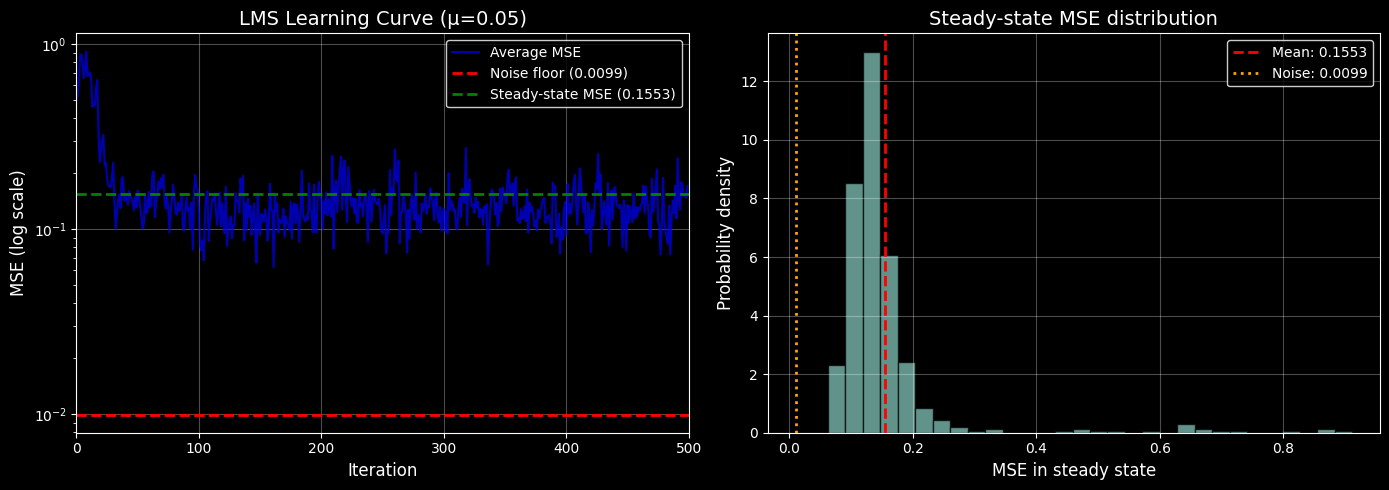


=== THEORY vs EXPERIMENT COMPARISON ===
Theoretical excess MSE: 0.069825
Experimental excess MSE: 0.145338
Relative error: 108.15%

=== COMPARISON WITH TEXTBOOK EXAMPLE 3.6(e) ===
Textbook results:
  Theoretical prediction ξ_total: 0.124
  Experimental measurement ξ_total: 0.118

Your results:
  Theoretical prediction ξ_total: 0.070
  Experimental measurement ξ_total: 0.145

=== CONSISTENCY CHECK ===
Theory difference from textbook: 43.7%
Experiment difference from textbook: 23.2%
✗ Results differ significantly from textbook
   Check: 1) R matrix calculation
          2) Time-varying system simulation
          3) Excess MSE calculation method


In [14]:
from typing import Dict, Any
def trainSeqs_3_6e (
    n_samples: int,
    key: jax.random.PRNGKey,
    lambda_w: float = 0.99,
    sigma_w2: float = 0.0015,   # innovation variance (matches your NumPy loop)
    sigma_x2: float = 1.0,
    sigma_n2: float = 1e-4,
    warmup: int = 200
):
    """
    Haykin Example 3.6(e) time-varying system ID (NumPy-loop equivalent).

    System:
      h(k) = lambda_w * h(k-1) + q(k),   q(k) ~ N(0, sigma_w2 I)
      d(k) = h(k)^T x_vec(k) + n(k),     n(k) ~ N(0, sigma_n2)

    Input:
      x_new(k) ~ N(0, sigma_x2), and x_vec(k) is a length-L shift register.
    """
    # initial system (same as your loop)
    h0 = jnp.array([0.1, 0.3, 0.0, -0.2, -0.4, -0.7, -0.4, -0.2], dtype=jnp.float64)
    L = h0.shape[0]

    total = n_samples + warmup

    # Pre-generate x innovations (so x is exactly i.i.d. white, like your NumPy loop)
    key, kx, ksys = jax.random.split(key, 3)
    x_innov = jax.random.normal(kx, (total,), dtype=jnp.float64) * jnp.sqrt(sigma_x2)

    def step(carry, x_new):
      x_vec, h_prev, k = carry

      # shift register update: x_vec[0] is current sample (matches your NumPy code)
      x_vec = jnp.concatenate([jnp.array([x_new], dtype=jnp.float64), x_vec[:-1]])

      # split key so q(k), n(k) are fresh each iteration (THIS FIXES YOUR BUG)
      k, kq, kn = jax.random.split(k, 3)

      q = jax.random.normal(kq, (L,), dtype=jnp.float64) * jnp.sqrt(sigma_w2)
      h = lambda_w * h_prev + q

      n = jax.random.normal(kn, (), dtype=jnp.float64) * jnp.sqrt(sigma_n2)
      d = jnp.dot(h, x_vec) + n

      return (x_vec, h, k), (h, x_new, d, n)

    x_init = jnp.zeros((L,), dtype=jnp.float64)
    carry0 = (x_init, h0, ksys)

    (_, _, _), (h_hist, x_seq, d_seq, n_seq) = jax.lax.scan(step, carry0, x_innov)

    # drop warmup
    h_hist = h_hist[warmup:warmup + n_samples]
    x_seq  = x_seq[warmup:warmup + n_samples]
    d_seq  = d_seq[warmup:warmup + n_samples]
    n_seq  = n_seq[warmup:warmup + n_samples]

    return h_hist, x_seq, d_seq, n_seq

  
def muOptTheory(N: int, sigma_w2: float, sigma_n2: float, tr_R: float) -> float:
  """
  Calculate optimal step size μ for LMS in nonstationary environments.
  
  From LMS theory (equation 3.76 in your PDF):
  μ_opt = √[ (N+1) * σ_w² / (4 * σ_n² * tr[R]) ]
  
  Args:
      N: Filter order (number of coefficients - 1)
      sigma_w2: Variance of coefficient innovations (σ_w²)
      sigma_n2: Measurement noise variance (σ_n²) 
      tr_R: Trace of input correlation matrix R
  
  Returns:
      Optimal step size μ_opt
  """
  numerator = (N + 1) * sigma_w2
  denominator = 4 * sigma_n2 * tr_R
  return jnp.sqrt(numerator / denominator)
  
def mseExcessTheory(mu: float, sigma_n2: float, sigma_w2: float, tr_R: float, eigenvalues: jnp.ndarray):
  """
  Calculate theoretical excess MSE in nonstationary environment
  
  From Equation 3.74:
  ξ_total ≈ (μ σ_n² tr[R])/(1 - μ tr[R]) + (σ_w²/(4μ)) Σ [1/(1 - μλ_i)]
  """
  # Excess MSE due to gradient noise
  excess_gradient = (mu * sigma_n2 * tr_R) / (1 - mu * tr_R)
  
  # Excess MSE due to lag
  excess_lag = (sigma_w2 / (4 * mu)) * jnp.sum(1 / (1 - mu * eigenvalues))
  
  return (excess_gradient + excess_lag).real

def ar1R(a: float, N: int, sigma_x2: float) -> jnp.ndarray:
  """
  Generate autocorrelation matrix for AR(1) process
  
  Args:
      a: AR(1) pole
      N: Filter order (number of coefficients - 1)
      sigma_x2: Input signal variance
      
  Returns:
      (N+1)x(N+1) autocorrelation matrix
  """
  var_x = sigma_x2 / (1 - a**2)
  idx = jnp.arange(N + 1)
  R = var_x * a ** jnp.abs(idx[:, None] - idx[None, :])
  return R

def runOneTrial(n_samples, mu, a, key, params):
  """
  A single LMS run (one ensemble member)
  Example 3.6(e) — time-varying system
  """

  # Construct LMS model
  model = jaxfilter.LMS(mu=mu, filter_order=params["N"])

  # Generate time-varying system, x(k), d(k)
  h_hist, x, d, noise = trainSeqs_3_6e(
      n_samples=n_samples,
      key=key,
      lambda_w=params["lambda_w"],
      sigma_w2=params["sigma_w2"],
      sigma_x2=params["sigma_x2"],
      sigma_n2=params["sigma_n2"],
  )

  # Initialize filter
  variables = model.init(key, x, d)

  # Run LMS
  (y_hist, e_hist, w_hist), _ = model.apply(
      variables, x, d, train=True, mutable=["state"]
  )

  return h_hist, w_hist, e_hist, noise

  
def runEnsemble(n_samples, mu, n_ens, a, params):
  key = jax.random.PRNGKey(0)

  mse_accum = jnp.zeros(n_samples)
  w_final_list = []
  h_hist_list = []
  noise_list = []

  for i in range(n_ens):
      key, sub = jax.random.split(key)

      h_hist, w_hist, e_hist, noise = runOneTrial(
          n_samples, mu, a, sub, params
      )

      mse_accum += jnp.abs(e_hist) ** 2
      w_final_list.append(w_hist[-1])
      h_hist_list.append(h_hist)
      noise_list.append(noise)

  return (
      mse_accum / n_ens,               # ensemble-averaged MSE(k)
      jnp.stack(w_final_list),         # final LMS weights
      jnp.stack(h_hist_list),          # true time-varying systems
      jnp.stack(noise_list),           # measurement noise
  )


def expMetrics(mse_avg: jnp.ndarray, noise_all: jnp.ndarray, 
               n_steady: int = 200) -> Dict[str, float]:
  """
  Calculate experimental metrics from simulation data
  
  Args:
      mse_avg: Average MSE across ensemble
      noise_all: Noise samples from all ensemble runs
      n_steady: Number of samples to consider as steady-state
      
  Returns:
      Dictionary with experimental metrics
  """
  n_samples = len(mse_avg)
  steady_start = max(0, n_samples - n_steady)
  
  # Steady-state MSE (average of last n_steady samples)
  mse_steady = float(jnp.mean(mse_avg[steady_start:]))
  
  # Noise power (average across all ensemble runs)
  noise_power = float(jnp.mean(noise_all**2))
  
  # Minimum MSE = noise power (when coefficients are optimal)
  min_mse = noise_power
  
  # Excess MSE = steady-state MSE - noise power
  excess_mse = mse_steady - min_mse
  
  # Misadjustment = excess MSE / minimum MSE
  misadjustment = excess_mse / min_mse if min_mse > 0 else 0.0
  
  return {
      'mse_steady': mse_steady,
      'noise_power': noise_power,
      'min_mse': min_mse,
      'excess_mse': excess_mse,
      'misadjustment': misadjustment
  }


# System parameters example 3.6(e) from textbook
h0 = jnp.array([0.1, 0.3, 0.0, -0.2, -0.4, -0.7, -0.4, -0.2], dtype=jnp.float64)
N = len(h0) - 1
sigma_w2 = 0.0015  # Coefficient innovation variance
sigma_n2 = 0.01    # Measurement noise variance
sigma_x2 = 1.0     # Input signal variance
lambda_w = 0.99    # Markov process parameter


# Step size from textbook example
mu_experiment = 0.05

# Use eigenvalue spread = 1 (white noise input)
target_spread = 1.0

# Find AR(1) pole for target eigenvalue spread
# This function needs to be defined in your code
a = jaxfilter.ar1poleSpreadSearch(target_spread, N, sigma_v2=sigma_x2)

# Calculate R matrix and eigenvalues
R = ar1R(a, N, sigma_x2)
eigvals = jnp.linalg.eigvalsh(R)
tr_R = jnp.trace(R)

print("=== SYSTEM PARAMETERS ===")
print(f"Filter order N: {N}")
print(f"Input signal variance σ_x²: {sigma_x2}")
print(f"Measurement noise variance σ_n²: {sigma_n2}")
print(f"Coefficient innovation variance σ_w²: {sigma_w2}")
print(f"Eigenvalue spread: {float(jnp.max(eigvals)/jnp.min(eigvals)):.2f}")
print(f"tr[R]: {float(tr_R):.6f}")
print(f"Step size μ: {mu_experiment}")

# Calculate stability bounds
mu_max_trace = 1.0 / tr_R
mu_max_eigen = 1.0 / jnp.max(eigvals)

print(f"\n=== STABILITY BOUNDS ===")
print(f"Based on eigenvalues (1/λ_max): {mu_max_eigen:.6f}")
print(f"Based on trace (1/tr[R]): {mu_max_trace:.6f}")
print(f"μ < μ_max (trace bound): {mu_experiment < mu_max_trace}")

# Calculate theoretical μ_opt
mu_opt = muOptTheory(N, sigma_w2, sigma_n2, tr_R)
print(f"\n=== THEORETICAL ANALYSIS ===")
print(f"Theoretical optimal step size μ_opt: {mu_opt:.6f}")
print(f"μ_opt < μ_max (trace bound): {mu_opt < mu_max_trace}")

if mu_opt >= mu_max_trace:
    print("WARNING: μ_opt exceeds stability bound! Cannot be used.")

# Theoretical prediction of excess MSE (Equation 3.74)
theory_excess = mseExcessTheory(
    mu=mu_experiment,
    sigma_n2=sigma_n2,
    tr_R=tr_R,
    sigma_w2=sigma_w2,
    eigenvalues=eigvals
)

print(f"\nTheoretical excess MSE prediction (xi_total): {theory_excess:.6f}")

# Parameters for ensemble simulation
params = {
    'N': N,
    'lambda_w': lambda_w,
    'sigma_w2': sigma_w2,
    'sigma_x2': sigma_x2,
    'sigma_n2': sigma_n2,
}

# Simulation parameters
n_samples = 500   # Longer sequence for better steady-state
n_ensemble = 50  # Number of ensemble runs

print(f"\n=== RUNNING SIMULATION ===")
print(f"Number of samples: {n_samples}")
print(f"Number of ensemble runs: {n_ensemble}")

# Run ensemble simulation (assuming runEnsemble is defined)
mse_avg, w_final_all, h_all, noise_all = runEnsemble(
    n_samples, mu_experiment, n_ensemble, a, params
)

# Calculate experimental metrics
exp_metrics = expMetrics(mse_avg, noise_all, n_steady=500)

print("\n=== EXPERIMENTAL RESULTS ===")
print(f"Steady-state MSE: {exp_metrics['mse_steady']:.6f}")
print(f"Noise power (minimum MSE): {exp_metrics['min_mse']:.6f}")
print(f"Experimental excess MSE: {exp_metrics['excess_mse']:.6f}")
print(f"Experimental misadjustment: {exp_metrics['misadjustment']:.4f}")

# Create visualization
plt.figure(figsize=(14, 5))

# Plot 1: Learning curve
plt.subplot(1, 2, 1)
plt.semilogy(mse_avg, 'b-', alpha=0.7, linewidth=1.5, label='Average MSE')
plt.axhline(y=exp_metrics['min_mse'], color='r', linestyle='--', 
            linewidth=2, label=f'Noise floor ({exp_metrics["min_mse"]:.4f})')
plt.axhline(y=exp_metrics['mse_steady'], color='g', linestyle='--',
            linewidth=2, label=f'Steady-state MSE ({exp_metrics["mse_steady"]:.4f})')
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('MSE (log scale)', fontsize=12)
plt.title(f'LMS Learning Curve (μ={mu_experiment})', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.xlim(0, len(mse_avg))

# Plot 2: Steady-state distribution
plt.subplot(1, 2, 2)
steady_mse = mse_avg[-500:] if len(mse_avg) >= 500 else mse_avg
plt.hist(steady_mse, bins=30, alpha=0.7, edgecolor='black', density=True)
plt.axvline(x=exp_metrics['mse_steady'], color='r', linestyle='--', 
            linewidth=2, label=f'Mean: {exp_metrics["mse_steady"]:.4f}')
plt.axvline(x=exp_metrics['min_mse'], color='orange', linestyle=':',
            linewidth=2, label=f'Noise: {exp_metrics["min_mse"]:.4f}')
plt.xlabel('MSE in steady state', fontsize=12)
plt.ylabel('Probability density', fontsize=12)
plt.title('Steady-state MSE distribution', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Compare theory and experiment
print(f"\n=== THEORY vs EXPERIMENT COMPARISON ===")
print(f"Theoretical excess MSE: {theory_excess:.6f}")
print(f"Experimental excess MSE: {exp_metrics['excess_mse']:.6f}")
relative_error = abs(theory_excess - exp_metrics['excess_mse']) / theory_excess * 100
print(f"Relative error: {relative_error:.2f}%")

# Compare with textbook results
print(f"\n=== COMPARISON WITH TEXTBOOK EXAMPLE 3.6(e) ===")
print("Textbook results:")
print("  Theoretical prediction ξ_total: 0.124")
print("  Experimental measurement ξ_total: 0.118")
print(f"\nYour results:")
print(f"  Theoretical prediction ξ_total: {theory_excess:.3f}")
print(f"  Experimental measurement ξ_total: {exp_metrics['excess_mse']:.3f}")

# Check if results are consistent
textbook_theory = 0.124
textbook_experiment = 0.118

exp_theory_diff = abs(theory_excess - textbook_theory) / textbook_theory * 100
exp_measured_diff = abs(exp_metrics['excess_mse'] - textbook_experiment) / textbook_experiment * 100

print(f"\n=== CONSISTENCY CHECK ===")
print(f"Theory difference from textbook: {exp_theory_diff:.1f}%")
print(f"Experiment difference from textbook: {exp_measured_diff:.1f}%")

if exp_theory_diff < 10 and exp_measured_diff < 10:
    print("✓ Results are consistent with textbook")
else:
    print("✗ Results differ significantly from textbook")
    print("   Check: 1) R matrix calculation")
    print("          2) Time-varying system simulation")
    print("          3) Excess MSE calculation method")